[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Laverde97/phd-data-science-ai/blob/main/semesters/semester-01/machine-learning/workshops/workshop-03-regresion-lineal-viviendas.ipynb)

# Taller práctico: Regresión lineal para predicción de precios de viviendas

**Autor: Juan Sebastian Laverde Chunza**

# 1. Carga y exploración de datos

En esta primera etapa se realiza la carga del conjunto de datos y una exploración inicial de su estructura.

El conjunto de datos contiene información sobre viviendas y está compuesto por dos variables principales:

- **tamaño**: tamaño de la vivienda expresado en metros cuadrados (m²).
- **precio**: precio de la vivienda expresado en pesos colombianos (COP).

El objetivo de esta exploración inicial es verificar las dimensiones del conjunto de datos, identificar la presencia de valores faltantes y obtener estadísticas descriptivas que permitan comprender el comportamiento de las variables antes de realizar cualquier transformación o modelado.

## Importación y carga de datos

In [ ]:
# ============================================================
# 1. CARGA DEL CONJUNTO DE DATOS
# ============================================================

import pandas as pd

# Cargar directamente el archivo CSV desde Google Cloud Storage
dataset = pd.read_csv(
    'https://storage.googleapis.com/backet_doctorado_ueb_2026_2/datos_viviendas_faltantes.csv'
)

# Visualizar los primeros registros
print("PRIMEROS REGISTROS DEL CONJUNTO DE DATOS")
print("=" * 60)

display(dataset.head(10))

PRIMEROS REGISTROS DEL CONJUNTO DE DATOS


,tamano,precio
0,NaN,532530.0
1,143.8,351732.0
2,179.1,526522.0
3,218.5,565288.0
4,139.5,382380.0
5,NaN,401130.0
6,NaN,596775.0
7,184.5,427445.0
8,128.9,441341.0
9,174.4,542720.0


## Dimensiones y estructura del dataset
Cantidad de registros y columnas.

In [ ]:
# ============================================================
# 2. DIMENSIONES Y ESTRUCTURA DEL CONJUNTO DE DATOS
# ============================================================

print("DIMENSIONES DEL CONJUNTO DE DATOS")
print("=" * 60)

print(f"Número de registros : {dataset.shape[0]:,}")
print(f"Número de columnas  : {dataset.shape[1]}")

print("\nNOMBRES DE LAS COLUMNAS")
print("=" * 60)

print(list(dataset.columns))

DIMENSIONES DEL CONJUNTO DE DATOS
Número de registros : 100,000
Número de columnas  : 2

NOMBRES DE LAS COLUMNAS
['tamano', 'precio']


## Tipos de variables

In [ ]:
# ============================================================
# 3. TIPOS DE DATOS
# ============================================================

print("TIPOS DE DATOS")
print("=" * 60)

display(
    dataset.dtypes
           .rename("Tipo de dato")
           .to_frame()
)

TIPOS DE DATOS


,Tipo de dato
tamano,float64
precio,float64


## Identificación de valores faltantes

Verificación general de datos faltantes

In [ ]:
# Verificar si existe al menos un valor faltante en el dataset
hay_nulos = dataset.isnull().values.any()

print("¿El conjunto de datos contiene valores nulos?")
print("=" * 60)

print("Sí" if hay_nulos else "No")

¿El conjunto de datos contiene valores nulos?
Sí


In [ ]:
# ============================================================
# 4. IDENTIFICACIÓN DE VALORES NULOS
# ============================================================

valores_faltantes = dataset.isnull().sum()

tabla_faltantes = pd.DataFrame({
    'Variable': valores_faltantes.index,
    'Valores nulos': valores_faltantes.values
})

print("VALORES NULOS POR VARIABLE")
print("=" * 60)

display(tabla_faltantes)

VALORES NULOS POR VARIABLE


,Variable,Valores nulos
0,tamano,10000
1,precio,5000


## Estadísticas descriptivas

In [ ]:
# ============================================================
# 5. ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

variables_numericas = ['tamano', 'precio']

estadisticas_descriptivas = pd.DataFrame({
    'Cantidad': dataset[variables_numericas].count(),
    'Media': dataset[variables_numericas].mean(),
    'Mediana': dataset[variables_numericas].median(),
    'Desviación estándar': dataset[variables_numericas].std(),
    'Mínimo': dataset[variables_numericas].min(),
    'Primer cuartil (Q1)': dataset[variables_numericas].quantile(0.25),
    'Tercer cuartil (Q3)': dataset[variables_numericas].quantile(0.75),
    'Máximo': dataset[variables_numericas].max()
})

estadisticas_descriptivas.index.name = 'Variable'

print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

display(estadisticas_descriptivas.round(2))

ESTADÍSTICAS DESCRIPTIVAS


,Cantidad,Media,Mediana,Desviación estándar,Mínimo,Primer cuartil (Q1),Tercer cuartil (Q3),Máximo
Variable,,,,,,,,
tamano,90000,150.07,150.1,44.91,30.0,119.60,180.40,351.6
precio,95000,425238.13,425243.5,123138.41,30000.0,342106.75,508401.25,1002767.0


### Interpretación de la exploración inicial

La exploración inicial permite conocer la estructura y calidad del conjunto de datos antes de realizar cualquier procedimiento de preprocesamiento.

El dataset está conformado por las variables **tamaño** y **precio**, ambas de naturaleza cuantitativa continua. La variable `tamaño` representa el área de las viviendas en metros cuadrados, mientras que `precio` corresponde al valor de las viviendas en pesos colombianos.

El análisis de valores faltantes confirma la existencia de observaciones incompletas en el conjunto de datos. En esta etapa no se realiza ninguna eliminación ni imputación, ya que el tratamiento de estos valores será desarrollado posteriormente como parte del proceso de preparación de los datos.

Las estadísticas descriptivas permiten analizar la tendencia central y la dispersión de ambas variables. La comparación entre la media y la mediana será especialmente útil para identificar posibles asimetrías o la influencia de valores extremos antes de construir el modelo de regresión lineal.

##Gráfica 1 — Distribución del tamaño

Esta gráfica nos permite observar si los tamaños están concentrados en determinados intervalos y comparar visualmente media y mediana.

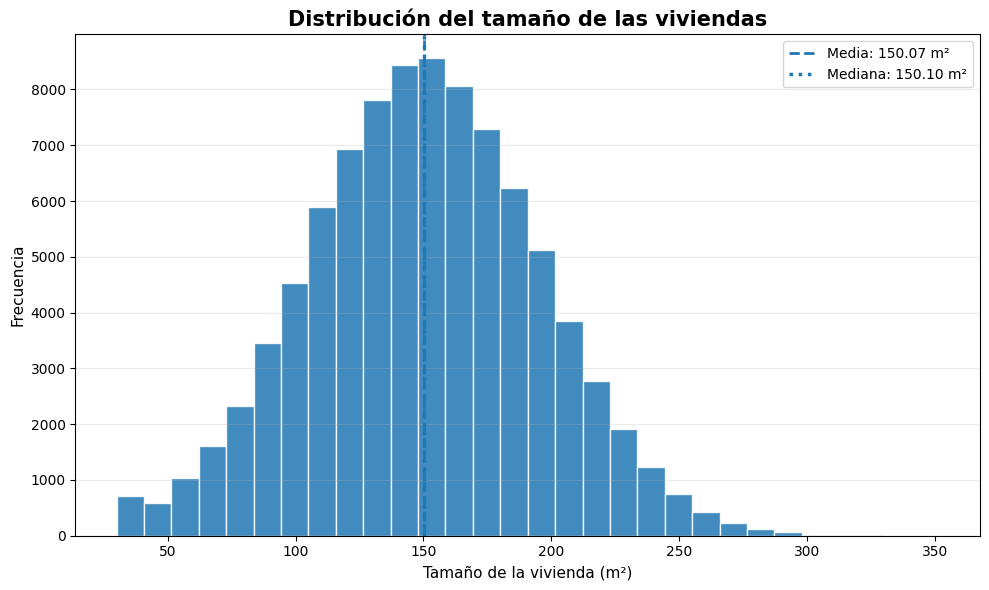

In [ ]:
# ============================================================
# 6. DISTRIBUCIÓN DEL TAMAÑO DE LAS VIVIENDAS
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    dataset['tamano'].dropna(),
    bins=30,
    edgecolor='white',
    alpha=0.85
)

# Media y mediana
media_tamano = dataset['tamano'].mean()
mediana_tamano = dataset['tamano'].median()

plt.axvline(
    media_tamano,
    linestyle='--',
    linewidth=2,
    label=f'Media: {media_tamano:,.2f} m²'
)

plt.axvline(
    mediana_tamano,
    linestyle=':',
    linewidth=2.5,
    label=f'Mediana: {mediana_tamano:,.2f} m²'
)

plt.title(
    'Distribución del tamaño de las viviendas',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Tamaño de la vivienda (m²)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

Gráfica 2 — Distribución del precio

Para el precio conviene evitar que Python muestre números como `2.5e8` (Notación cientifica). Podemos darle formato de pesos.

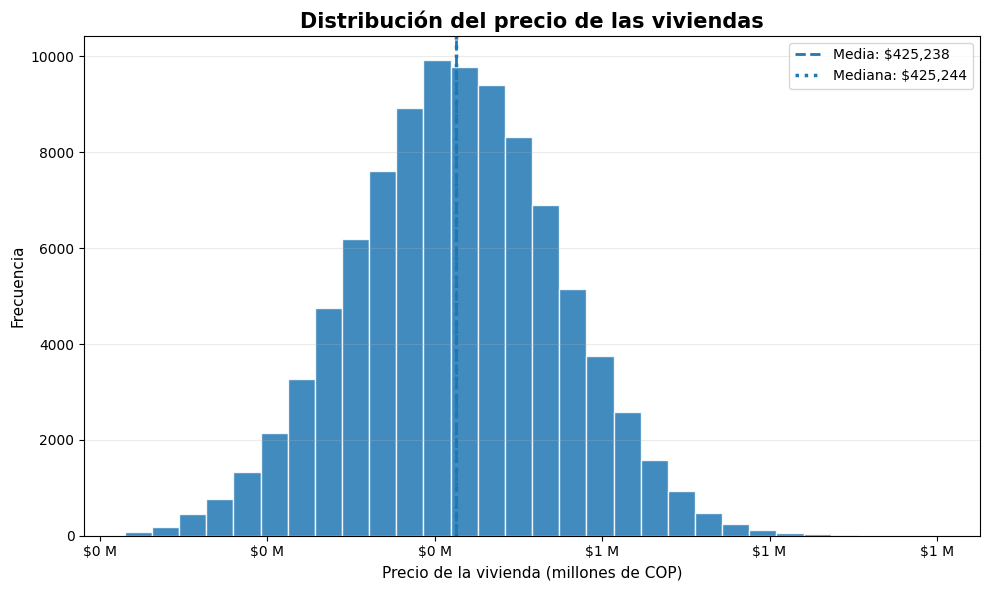

In [ ]:
# ============================================================
# 7. DISTRIBUCIÓN DEL PRECIO DE LAS VIVIENDAS
# ============================================================

from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

plt.hist(
    dataset['precio'].dropna(),
    bins=30,
    edgecolor='white',
    alpha=0.85
)

# Media y mediana
media_precio = dataset['precio'].mean()
mediana_precio = dataset['precio'].median()

plt.axvline(
    media_precio,
    linestyle='--',
    linewidth=2,
    label=f'Media: ${media_precio:,.0f}'
)

plt.axvline(
    mediana_precio,
    linestyle=':',
    linewidth=2.5,
    label=f'Mediana: ${mediana_precio:,.0f}'
)

# Formato del eje X en millones de pesos
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:,.0f} M')
)

plt.title(
    'Distribución del precio de las viviendas',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Precio de la vivienda (millones de COP)', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)

plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

## Gráfica 3 — Boxplot del tamaño

Ahora podemos comprobar visualmente la existencia de posibles valores extremos.

Con este gráfico podemos observar:

- mediana;
- rango intercuartílico;
- dispersión;
- posibles valores atípicos.

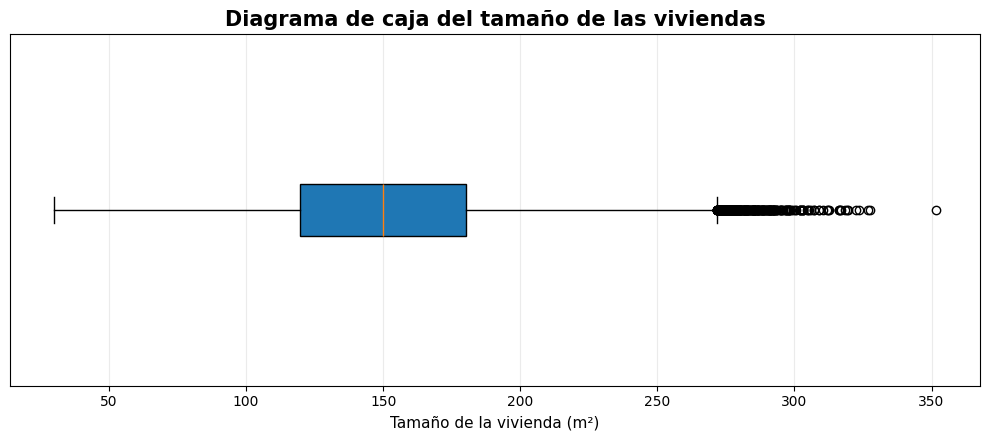

In [ ]:
# ============================================================
# 8. DIAGRAMA DE CAJA DEL TAMAÑO
# ============================================================

plt.figure(figsize=(10, 4.5))

plt.boxplot(
    dataset['tamano'].dropna(),
    vert=False,
    patch_artist=True
)

plt.title(
    'Diagrama de caja del tamaño de las viviendas',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Tamaño de la vivienda (m²)', fontsize=11)
plt.yticks([])

plt.grid(axis='x', alpha=0.25)
plt.tight_layout()

plt.show()

## Gráfica 4 — Boxplot del precio

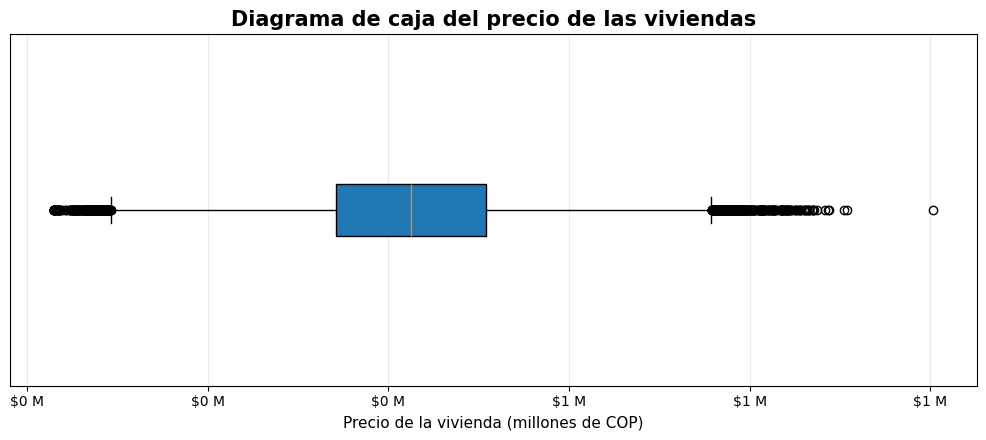

In [ ]:
# ============================================================
# 9. DIAGRAMA DE CAJA DEL PRECIO
# ============================================================

plt.figure(figsize=(10, 4.5))

plt.boxplot(
    dataset['precio'].dropna(),
    vert=False,
    patch_artist=True
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:,.0f} M')
)

plt.title(
    'Diagrama de caja del precio de las viviendas',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Precio de la vivienda (millones de COP)', fontsize=11)
plt.yticks([])

plt.grid(axis='x', alpha=0.25)
plt.tight_layout()

plt.show()

## Gráfica 5 — Tamaño vs. precio

Nota: Para construirla correctamente debemos omitir únicamente para la visualización aquellas observaciones donde falte alguna de las dos variables.

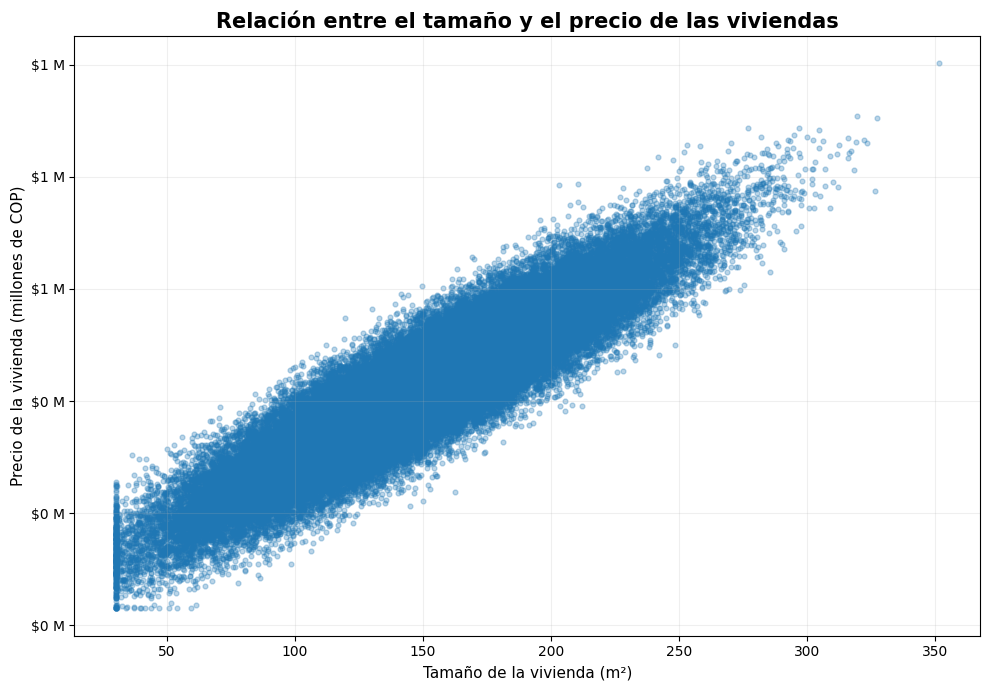

In [ ]:
# ============================================================
# 10. RELACIÓN ENTRE TAMAÑO Y PRECIO
# ============================================================

# Dataset temporal únicamente para la visualización
datos_grafica = dataset[['tamano', 'precio']].dropna()

plt.figure(figsize=(10, 7))

plt.scatter(
    datos_grafica['tamano'],
    datos_grafica['precio'],
    alpha=0.30,
    s=12
)

# Formato del eje Y en millones de pesos
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x/1_000_000:,.0f} M')
)

plt.title(
    'Relación entre el tamaño y el precio de las viviendas',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Tamaño de la vivienda (m²)', fontsize=11)
plt.ylabel('Precio de la vivienda (millones de COP)', fontsize=11)

plt.grid(alpha=0.20)
plt.tight_layout()

plt.show()

### Análisis exploratorio gráfico

Las representaciones gráficas complementan las estadísticas descriptivas y permiten obtener una visión inicial del comportamiento de las variables.

Los histogramas permiten analizar la forma de las distribuciones de `tamaño` y `precio`, mientras que los diagramas de caja facilitan la identificación de posibles valores extremos y la dispersión de los datos.

Por su parte, el gráfico de dispersión permite estudiar visualmente la relación existente entre el tamaño de las viviendas y su precio. Esta relación resulta especialmente relevante para el desarrollo posterior del taller, dado que `tamaño` será utilizado como variable independiente o predictora y `precio` como variable dependiente u objetivo.

En esta fase no se han eliminado ni imputado observaciones. Los valores faltantes serán tratados formalmente en la siguiente sección.

# 2. Tratamiento de datos faltantes (Imputación)

La presencia de valores faltantes constituye un aspecto crítico dentro de la preparación de los datos, debido a que puede afectar tanto el análisis estadístico como el entrenamiento posterior del modelo de regresión.

En esta sección se desarrollan cuatro etapas:

1. Cuantificación de los valores faltantes.
2. Análisis del patrón de datos faltantes.
3. Comparación de diferentes estrategias de imputación.
4. Selección y aplicación del método de imputación más adecuado.

La elección del método no se realizará únicamente por simplicidad. Se compararán métodos univariados y multivariados con el propósito de seleccionar una estrategia que preserve, en la medida de lo posible, la distribución de las variables y la relación existente entre el tamaño y el precio de las viviendas.

### 2.1 Guardar el patrón original de faltantes

Antes de imputar guardamos cuáles observaciones tenían originalmente datos faltantes:

In [ ]:
# ============================================================
# 2.1 REGISTRO DEL PATRÓN ORIGINAL DE VALORES FALTANTES
# ============================================================

# Guardar máscaras antes de realizar cualquier imputación
faltante_original_tamano = dataset['tamano'].isna().copy()
faltante_original_precio = dataset['precio'].isna().copy()

print("Patrón original de valores faltantes almacenado correctamente.")

Patrón original de valores faltantes almacenado correctamente.


¿Por qué?

Porque más adelante podremos saber:

Qué precios fueron observados realmente y cuáles fueron imputados.

Esto será especialmente importante en la parte de regresión.

In [ ]:
faltante_original_precio

,precio
0,False
1,False
2,False
3,False
4,False
...,...
99995,True
99996,False
99997,False
99998,False


## 2.2 Cantidad y porcentaje de valores faltantes

In [ ]:
# ============================================================
# 2.2 CANTIDAD Y PORCENTAJE DE VALORES FALTANTES
# ============================================================

resumen_faltantes = pd.DataFrame({
    'Variable': dataset.columns,
    'Valores faltantes': dataset.isnull().sum().values,
    'Valores observados': dataset.notnull().sum().values,
    'Porcentaje faltante (%)': (
        dataset.isnull().mean() * 100
    ).round(2).values
})

print("RESUMEN DE VALORES FALTANTES")
print("=" * 70)

display(resumen_faltantes)

RESUMEN DE VALORES FALTANTES


,Variable,Valores faltantes,Valores observados,Porcentaje faltante (%)
0,tamano,10000,90000,10.0
1,precio,5000,95000,5.0


## 2.3 Gráfica del porcentaje de valores faltantes

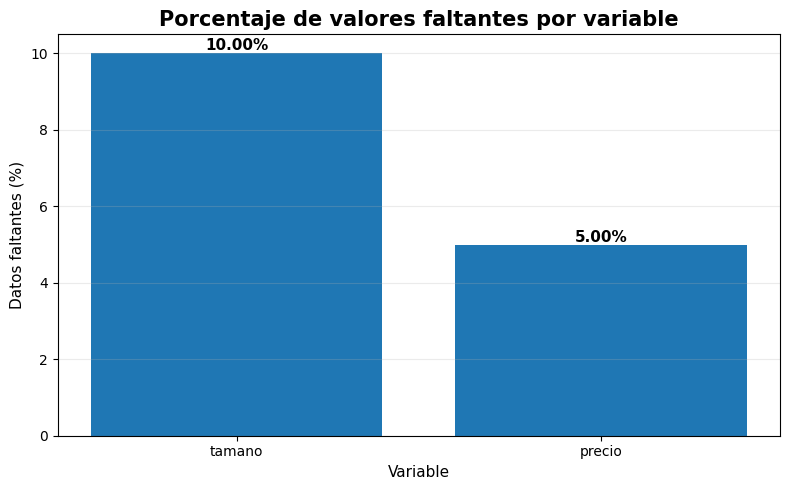

In [ ]:
# ============================================================
# 2.3 VISUALIZACIÓN DEL PORCENTAJE DE DATOS FALTANTES
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

barras = plt.bar(
    resumen_faltantes['Variable'],
    resumen_faltantes['Porcentaje faltante (%)']
)

plt.title(
    'Porcentaje de valores faltantes por variable',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Variable', fontsize=11)
plt.ylabel('Datos faltantes (%)', fontsize=11)

# Mostrar porcentaje encima de cada barra
for barra, porcentaje in zip(
    barras,
    resumen_faltantes['Porcentaje faltante (%)']
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f'{porcentaje:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

plt.show()

## 2.4 Analizar el patrón de faltantes

No basta con saber cuántos faltan. También quiero conocer si tenemos:

- filas donde falta solamente `tamaño`;
- filas donde falta solamente `precio`;
- filas donde faltan ambas;
- filas completamente observadas.

Usaremos:

In [ ]:
# ============================================================
# 2.4 PATRONES DE VALORES FALTANTES
# ============================================================

patrones_faltantes = (
    dataset[['tamano', 'precio']]
    .isnull()
    .value_counts()
    .reset_index(name='Frecuencia')
)

patrones_faltantes['tamano'] = patrones_faltantes['tamano'].map({
    False: 'Observado',
    True: 'Faltante'
})

patrones_faltantes['precio'] = patrones_faltantes['precio'].map({
    False: 'Observado',
    True: 'Faltante'
})

patrones_faltantes['Porcentaje (%)'] = (
    patrones_faltantes['Frecuencia']
    / len(dataset)
    * 100
).round(2)

print("PATRONES DE VALORES FALTANTES")
print("=" * 70)

display(patrones_faltantes)

PATRONES DE VALORES FALTANTES


,tamano,precio,Frecuencia,Porcentaje (%)
0,Observado,Observado,85501,85.5
1,Faltante,Observado,9499,9.5
2,Observado,Faltante,4499,4.5
3,Faltante,Faltante,501,0.5


## 2.5 ¿Por qué no escoger directamente media o mediana?

## Evaluación de estrategias de imputación

Existen diferentes alternativas para tratar los valores faltantes. Sin embargo, no todas utilizan la misma cantidad de información.

### Eliminación de observaciones

Eliminar las filas incompletas constituye una estrategia sencilla, pero implica perder información disponible y puede reducir innecesariamente el tamaño de la muestra. Además, si los datos faltantes no se presentan completamente al azar, la eliminación podría introducir sesgos.

### Imputación por la media

Reemplaza los valores faltantes por el promedio de cada variable. Su principal ventaja es la simplicidad, pero todos los valores imputados reciben exactamente el mismo valor. Esto puede reducir artificialmente la variabilidad de los datos y no considera la relación entre `tamaño` y `precio`.

### Imputación por la mediana

Es más robusta frente a valores extremos que la media, pero continúa siendo un procedimiento univariado. Es decir, el valor imputado de `precio` no utiliza información sobre el `tamaño` de la vivienda y viceversa.

### Imputación KNN

KNN utiliza observaciones similares para estimar los valores faltantes. Puede capturar relaciones locales y no requiere asumir linealidad. Sin embargo, puede ser computacionalmente costoso en conjuntos de datos grandes y su comportamiento depende de la elección del número de vecinos.

### Imputación iterativa

La imputación iterativa modela cada variable con valores faltantes como función de las demás variables disponibles. En este problema resulta especialmente atractiva porque `tamaño` y `precio` son variables numéricas y presentan una relación aproximadamente lineal.

Por esta razón se evaluará `IterativeImputer` utilizando `BayesianRidge`, junto con métodos más simples, antes de tomar la decisión definitiva.

## 2.6 Vamos a demostrar cuál método imputa mejor

In [ ]:
# ============================================================
# 2.6 COMPARACIÓN DE MÉTODOS DE IMPUTACIÓN
# ============================================================

import numpy as np

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import (
    SimpleImputer,
    KNNImputer,
    IterativeImputer
)

from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone

## 2.7 Preparar datos para validar los imputadores

No tenemos que utilizar los 100.000 registros para comparar KNN, porque aumentaría innecesariamente el costo computacional.

Usaremos una muestra reproducible de hasta 5.000 registros completos.

In [ ]:
# ============================================================
# DATOS COMPLETOS PARA VALIDACIÓN DE LOS IMPUTADORES
# ============================================================

variables = ['tamano', 'precio']

datos_completos = (
    dataset[variables]
    .dropna()
    .copy()
)

# Tomar una muestra para hacer eficiente la comparación,
# especialmente para KNN
n_muestra = min(5000, len(datos_completos))

muestra_validacion = datos_completos.sample(
    n=n_muestra,
    random_state=42
)

print(f"Registros completos disponibles : {len(datos_completos):,}")
print(f"Registros usados en validación  : {len(muestra_validacion):,}")

Registros completos disponibles : 85,501
Registros usados en validación  : 5,000


Importante: esto no elimina filas del dataset original.

Solo estamos construyendo una muestra experimental para evaluar los métodos.

## 2.8 Crear artificialmente valores faltantes

Aquí ocultaremos el 10% solamente para la evaluación.

In [ ]:
# ============================================================
# FUNCIÓN PARA INTRODUCIR VALORES FALTANTES ARTIFICIALES
# ============================================================

def introducir_faltantes(datos, proporcion=0.10, random_state=42):

    datos_incompletos = datos.copy()
    generador = np.random.default_rng(random_state)

    for columna in datos_incompletos.columns:

        n_faltantes = int(
            len(datos_incompletos) * proporcion
        )

        indices = generador.choice(
            datos_incompletos.index,
            size=n_faltantes,
            replace=False
        )

        datos_incompletos.loc[
            indices,
            columna
        ] = np.nan

    return datos_incompletos

## 2.9 Métodos que vamos a comparar

Fíjate en: `min_value=0`, esto tiene sentido porque conceptualmente un precio o un tamaño negativo no serían valores válidos para este problema.

In [ ]:
# ============================================================
# MÉTODOS DE IMPUTACIÓN A COMPARAR
# ============================================================

metodos_imputacion = {

    'Media':
        SimpleImputer(
            strategy='mean'
        ),

    'Mediana':
        SimpleImputer(
            strategy='median'
        ),

    'KNN (k=5)':
        KNNImputer(
            n_neighbors=5,
            weights='distance'
        ),

    'Iterativo + BayesianRidge':
        IterativeImputer(
            estimator=BayesianRidge(),
            initial_strategy='median',
            max_iter=15,
            random_state=42,
            min_value=0
        )
}

## 2.10 Comparación empírica

In [ ]:
# ============================================================
# EVALUACIÓN DE LOS MÉTODOS DE IMPUTACIÓN
# ============================================================

resultados = []

# Separar datos para entrenamiento y validación
datos_train, datos_test = train_test_split(
    muestra_validacion,
    test_size=0.20,
    random_state=42
)

# Introducir datos faltantes artificialmente en entrenamiento
datos_train_incompletos = introducir_faltantes(
    datos_train,
    proporcion=0.10,
    random_state=42
)

for nombre_metodo, metodo in metodos_imputacion.items():

    # Crear copia independiente del imputador
    imputador = clone(metodo)

    # Ajustar el imputador
    imputador.fit(datos_train_incompletos)

    # --------------------------------------------------------
    # Evaluar la reconstrucción de cada variable
    # --------------------------------------------------------

    for variable in variables:

        datos_prueba = datos_test.copy()

        # Ocultamos temporalmente la variable
        # cuyo valor verdadero conocemos
        datos_prueba[variable] = np.nan

        # Realizar imputación
        datos_estimados = pd.DataFrame(
            imputador.transform(datos_prueba),
            columns=variables,
            index=datos_prueba.index
        )

        y_real = datos_test[variable].values
        y_estimado = datos_estimados[variable].values

        # Métricas
        mae = mean_absolute_error(
            y_real,
            y_estimado
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_real,
                y_estimado
            )
        )

        # Normalizar RMSE para poder comparar
        # variables con escalas diferentes
        desviacion = np.std(
            y_real,
            ddof=1
        )

        nrmse = rmse / desviacion

        resultados.append({
            'Método': nombre_metodo,
            'Variable': variable,
            'MAE': mae,
            'RMSE': rmse,
            'NRMSE': nrmse
        })

## 2.11 Tabla de resultados

In [ ]:
# ============================================================
# RESULTADOS DE LA COMPARACIÓN
# ============================================================

resultados_imputacion = pd.DataFrame(resultados)

print("DESEMPEÑO DE LOS MÉTODOS DE IMPUTACIÓN")
print("=" * 80)

display(
    resultados_imputacion
    .round(4)
)

DESEMPEÑO DE LOS MÉTODOS DE IMPUTACIÓN


,Método,Variable,MAE,RMSE,NRMSE
0,Media,tamano,36.5792,45.5386,0.9996
1,Media,precio,102326.4188,126228.5367,0.9999
2,Mediana,tamano,36.5844,45.5351,0.9995
3,Mediana,precio,102320.9120,126221.9647,0.9999
4,KNN (k=5),tamano,16.6875,21.1176,0.4635
5,KNN (k=5),precio,48924.6565,61428.0471,0.4866
6,Iterativo + BayesianRidge,tamano,14.3914,17.8956,0.3928
7,Iterativo + BayesianRidge,precio,39788.7054,49530.4828,0.3923


### Interpretación de los métodos de imputación

Se compararon cuatro métodos de imputación utilizando **MAE, RMSE y NRMSE**, donde valores menores indican mejor capacidad de reconstrucción.

La **media** y la **mediana** presentaron los peores resultados, con un NRMSE promedio cercano a **1.00**, debido a que no aprovechan la relación entre `tamano` y `precio`.

El método **KNN** mejoró considerablemente el desempeño, con un NRMSE promedio de **0.4751**.

El mejor resultado fue obtenido por **IterativeImputer + BayesianRidge**, con un NRMSE promedio de **0.3926**, siendo el método con menor error para ambas variables.

Por esta razón, se selecciona **IterativeImputer con BayesianRidge** como método definitivo de imputación, ya que presentó la mejor capacidad de reconstrucción y aprovecha la relación existente entre `tamano` y `precio`.


## 2.12 Ranking general de los métodos

Como precio y tamaño manejan escalas completamente diferentes, no podemos promediar directamente sus RMSE.

Por eso utilizamos el `NRMSE`.

In [ ]:
# ============================================================
# RANKING GENERAL
# ============================================================

ranking_imputacion = (
    resultados_imputacion
    .groupby('Método', as_index=False)
    .agg(
        NRMSE_promedio=('NRMSE', 'mean')
    )
    .sort_values(
        'NRMSE_promedio'
    )
    .reset_index(drop=True)
)

ranking_imputacion.index = (
    ranking_imputacion.index + 1
)

print("RANKING DE MÉTODOS DE IMPUTACIÓN")
print("=" * 70)
print("Menor NRMSE = mejor capacidad de reconstrucción\n")

display(
    ranking_imputacion.round(4)
)

RANKING DE MÉTODOS DE IMPUTACIÓN
Menor NRMSE = mejor capacidad de reconstrucción



,Método,NRMSE_promedio
1,Iterativo + BayesianRidge,0.3926
2,KNN (k=5),0.4751
3,Mediana,0.9997
4,Media,0.9997


## 2.13 Gráfica comparativa

Menor `NRMSE` = mejor método de reconstrucción.



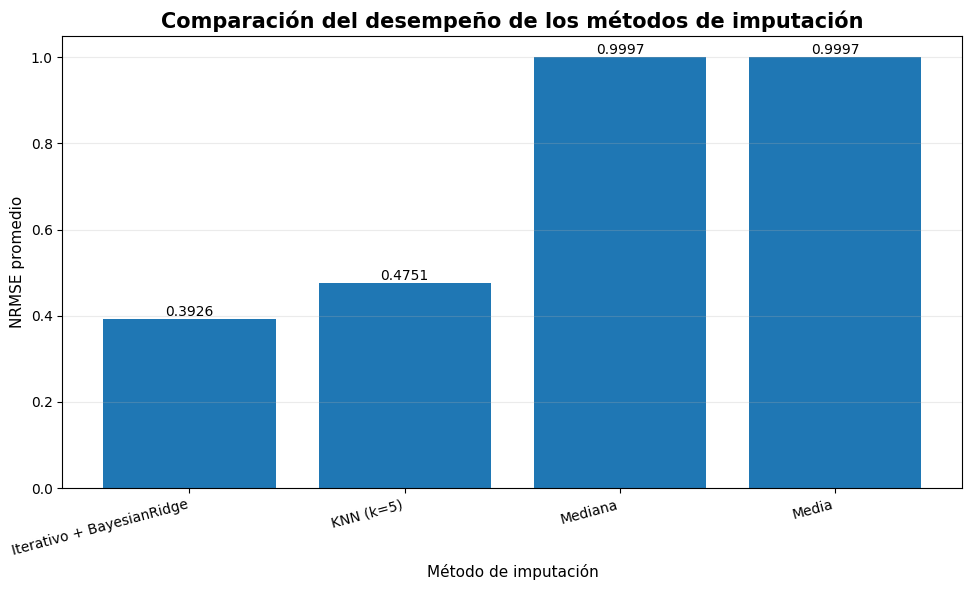

In [ ]:
# ============================================================
# COMPARACIÓN GRÁFICA DE LOS MÉTODOS DE IMPUTACIÓN
# ============================================================

plt.figure(figsize=(10, 6))

barras = plt.bar(
    ranking_imputacion['Método'],
    ranking_imputacion['NRMSE_promedio']
)

plt.title(
    'Comparación del desempeño de los métodos de imputación',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Método de imputación', fontsize=11)
plt.ylabel('NRMSE promedio', fontsize=11)

plt.xticks(
    rotation=15,
    ha='right'
)

for barra, valor in zip(
    barras,
    ranking_imputacion['NRMSE_promedio']
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f'{valor:.4f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.grid(axis='y', alpha=0.25)
plt.tight_layout()

plt.show()

## 2.14 Método que recomiendo: IterativeImputer + BayesianRidge

In [ ]:
IterativeImputer(
    estimator=BayesianRidge(),
    initial_strategy='median',
    max_iter=15,
    random_state=42,
    min_value=0
)

IterativeImputer(estimator=BayesianRidge(), initial_strategy='median',
                 max_iter=15, min_value=0, random_state=42)

¿Por qué este y no Random Forest, MissForest u otro todavía más avanzado?

Porque el propio problema nos dice que la relación es aproximadamente lineal. Usar Random Forest únicamente por ser más sofisticado añadiría complejidad sin una justificación estructural clara. `IterativeImputer` puede efectuar una regresión en rondas, considerando cada variable como variable a estimar, y `scikit-learn` documenta `BayesianRidge` como uno de sus estimadores de referencia.

Aquí “más avanzado” no significa automáticamente “mejor”.

## 2.15 Aplicar finalmente la imputación

In [ ]:
# ============================================================
# 2.15 IMPUTACIÓN DEFINITIVA
# ============================================================

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

imputador_final = IterativeImputer(
    estimator=BayesianRidge(),
    initial_strategy='median',
    max_iter=15,
    random_state=42,
    min_value=0
)

# Crear una copia para conservar el dataset original
dataset_limpio = dataset.copy()

# Imputar las dos variables numéricas
dataset_limpio[['tamano', 'precio']] = (
    imputador_final.fit_transform(
        dataset[['tamano', 'precio']]
    )
)

print("Imputación finalizada correctamente.")

Imputación finalizada correctamente.


## 2.16 Verificar que ya no existan faltantes

In [ ]:
# ============================================================
# 2.16 VERIFICACIÓN DEL DATASET IMPUTADO
# ============================================================

verificacion_final = pd.DataFrame({
    'Variable': dataset_limpio.columns,
    'Valores faltantes': (
        dataset_limpio
        .isnull()
        .sum()
        .values
    ),
    'Porcentaje faltante (%)': (
        dataset_limpio
        .isnull()
        .mean()
        .mul(100)
        .round(2)
        .values
    )
})

print("VERIFICACIÓN POSTERIOR A LA IMPUTACIÓN")
print("=" * 70)

display(verificacion_final)

VERIFICACIÓN POSTERIOR A LA IMPUTACIÓN


,Variable,Valores faltantes,Porcentaje faltante (%)
0,tamano,0,0.0
1,precio,0,0.0


## 2.17 Comprobar que no cambiamos los valores originales

In [ ]:
# ============================================================
# 2.17 VERIFICACIÓN DE CONSERVACIÓN DE DATOS OBSERVADOS
# ============================================================

tamaño_conservado = np.allclose(
    dataset.loc[
        ~faltante_original_tamano,
        'tamano'
    ],
    dataset_limpio.loc[
        ~faltante_original_tamano,
        'tamano'
    ]
)

precio_conservado = np.allclose(
    dataset.loc[
        ~faltante_original_precio,
        'precio'
    ],
    dataset_limpio.loc[
        ~faltante_original_precio,
        'precio'
    ]
)

print("CONSERVACIÓN DE LOS VALORES ORIGINALES")
print("=" * 70)

print(
    f"Valores observados de tamaño conservados : "
    f"{'Sí' if tamaño_conservado else 'No'}"
)

print(
    f"Valores observados de precio conservados : "
    f"{'Sí' if precio_conservado else 'No'}"
)

CONSERVACIÓN DE LOS VALORES ORIGINALES
Valores observados de tamaño conservados : Sí
Valores observados de precio conservados : Sí


## 2.18 Comparar estadísticos antes y después

In [ ]:
# ============================================================
# 2.18 COMPARACIÓN ANTES Y DESPUÉS DE LA IMPUTACIÓN
# ============================================================

comparacion = pd.DataFrame({

    'Media antes': dataset[
        ['tamano', 'precio']
    ].mean(),

    'Media después': dataset_limpio[
        ['tamano', 'precio']
    ].mean(),

    'Mediana antes': dataset[
        ['tamano', 'precio']
    ].median(),

    'Mediana después': dataset_limpio[
        ['tamano', 'precio']
    ].median(),

    'Desv. estándar antes': dataset[
        ['tamano', 'precio']
    ].std(),

    'Desv. estándar después': dataset_limpio[
        ['tamano', 'precio']
    ].std()
})

comparacion.index.name = 'Variable'

display(
    comparacion.round(2)
)

,Media antes,Media después,Mediana antes,Mediana después,Desv. estándar antes,Desv. estándar después
Variable,,,,,,
tamano,150.07,150.09,150.1,150.11,44.91,44.49
precio,425238.13,425304.47,425243.5,425349.02,123138.41,122437.23


### Interpretación

Las estadísticas antes y después de la imputación son **muy similares**. La media y la mediana de `tamano` y `precio` presentan cambios mínimos, mientras que la desviación estándar disminuye ligeramente.

Esto indica que el método de imputación seleccionado **conserva adecuadamente la tendencia central y la dispersión de los datos**, sin alterar de forma importante la distribución original. Por tanto, la imputación puede considerarse consistente con la estructura del conjunto de datos.


## 2.19 Una comprobación especialmente relevante para nuestra regresión

Comparemos la relación lineal antes y después:

In [ ]:
# ============================================================
# 2.19 CORRELACIÓN ANTES Y DESPUÉS DE LA IMPUTACIÓN
# ============================================================

correlacion_antes = (
    dataset[['tamano', 'precio']]
    .corr()
    .loc['tamano', 'precio']
)

correlacion_despues = (
    dataset_limpio[['tamano', 'precio']]
    .corr()
    .loc['tamano', 'precio']
)

print("CORRELACIÓN ENTRE TAMAÑO Y PRECIO")
print("=" * 70)

print(
    f"Antes de la imputación   : "
    f"{correlacion_antes:.4f}"
)

print(
    f"Después de la imputación : "
    f"{correlacion_despues:.4f}"
)

CORRELACIÓN ENTRE TAMAÑO Y PRECIO
Antes de la imputación   : 0.9143
Después de la imputación : 0.9252


### Justificación de la estrategia de imputación

Se compararon métodos simples y multivariados de imputación. La **media** y la **mediana** no aprovechan la relación entre `tamaño` y `precio`, mientras que **KNN** e **IterativeImputer** sí utilizan información conjunta de las variables.

Con base en los resultados de validación, se seleccionó **IterativeImputer con BayesianRidge**, ya que presentó el menor error de reconstrucción y permitió completar los datos conservando adecuadamente la estructura original del conjunto.


# 3. Construcción del modelo de regresión lineal

En esta etapa se construye un modelo de **regresión lineal simple** para estimar el precio de una vivienda a partir de su tamaño.

Se utilizarán las siguientes variables:

- **Variable independiente (X):** `tamano`
- **Variable dependiente (y):** `precio`

El conjunto de datos se dividirá en:

- **80 % para entrenamiento:** utilizado para ajustar el modelo.
- **20 % para prueba:** reservado para evaluar posteriormente su capacidad predictiva.

Una vez completado el proceso de imputación, se utiliza el dataset limpio completo para construir el modelo de regresión lineal. La variable predictora es `tamano` y la variable objetivo es `precio`. El conjunto completo de 100.000 observaciones imputadas se divide en 80 % para entrenamiento y 20 % para prueba.

## 3.1 Preparar el dataset para modelamiento
Aquí definimos las variables predictora y objetivo a partir del dataset limpio completo:

In [ ]:
# ============================================================
# 3.1 DEFINICIÓN DE VARIABLES DEL MODELO
# ============================================================

# Variable independiente o predictora
X = dataset_limpio[['tamano']]

# Variable dependiente u objetivo
y = dataset_limpio['precio']

print("VARIABLES DEL MODELO")
print("=" * 70)

print(f"Variable predictora (X): {list(X.columns)}")
print(f"Variable objetivo (y): {y.name}")

print(f"\nDimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

VARIABLES DEL MODELO
Variable predictora (X): ['tamano']
Variable objetivo (y): precio

Dimensiones de X: (100000, 1)
Dimensiones de y: (100000,)


Se utiliza el **dataset completo después de la imputación**, compuesto por 100.000 registros. `tamano` se define como variable predictora y `precio` como variable objetivo.


## 3.2 División 80 % / 20 %

In [ ]:
# ============================================================
# 3.2 DIVISIÓN EN ENTRENAMIENTO Y PRUEBA
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0
)

print("DIVISIÓN DEL CONJUNTO DE DATOS")
print("=" * 70)

print(f"Entrenamiento (80 %): {len(X_train):,} registros")
print(f"Prueba        (20 %): {len(X_test):,} registros")

DIVISIÓN DEL CONJUNTO DE DATOS
Entrenamiento (80 %): 80,000 registros
Prueba        (20 %): 20,000 registros


El dataset imputado se dividió en **80.000 registros para entrenamiento (80 %)** y **20.000 para prueba (20 %)**. Se utilizó `random_state=0` para garantizar que la partición sea reproducible.


## 3.3 Entrenamiento del modelo

In [ ]:
# ============================================================
# 3.3 ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL
# ============================================================

from sklearn.linear_model import LinearRegression

# Crear el modelo
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

print("MODELO ENTRENADO CORRECTAMENTE")
print("=" * 70)

MODELO ENTRENADO CORRECTAMENTE


## 3.4 Parámetros obtenidos

In [ ]:
# ============================================================
# 3.4 PARÁMETROS DEL MODELO
# ============================================================

intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]

print("PARÁMETROS ESTIMADOS DEL MODELO")
print("=" * 70)

print(f"Intercepto (β₀): ${intercepto:,.2f}")
print(f"Coeficiente (β₁): ${coeficiente:,.2f} por m2")

print("\nECUACIÓN DEL MODELO")
print("=" * 70)

print(
    f"Precio estimado = "
    f"{intercepto:,.2f} + "
    f"{coeficiente:,.2f} × tamano"
)

PARÁMETROS ESTIMADOS DEL MODELO
Intercepto (β₀): $43,002.89
Coeficiente (β₁): $2,547.77 por m2

ECUACIÓN DEL MODELO
Precio estimado = 43,002.89 + 2,547.77 × tamano


### Interpretación de los parámetros

La ecuación estimada es:

$$
\widehat{Precio} = 43.002,89 + 2.547,77 \times tamano
$$

El **coeficiente de 2.547,77** indica que, en promedio, por cada **1 $m^{2}$ adicional**, el precio de la vivienda aumenta aproximadamente en **$2.547,77 COP**.

El **intercepto de $43.002,89 COP** representa el precio estimado cuando el tamaño es \(0\,m^{2}\); sin embargo, su interpretación práctica es limitada, ya que una vivienda de \(0\,m^{2}\) no tiene sentido real.



# 4. Evaluación del modelo

Una vez entrenado el modelo de regresión lineal, se evalúa su capacidad predictiva utilizando exclusivamente el conjunto de prueba.

Se calculan las siguientes métricas:

- **$R^{2}$ (coeficiente de determinación):** indica qué proporción de la variabilidad del precio es explicada por el tamaño de la vivienda.
- **RMSE (raíz del error cuadrático medio):** mide la magnitud promedio del error de predicción, penalizando con mayor intensidad los errores grandes.
- **MAPE (error porcentual absoluto medio):** expresa el error promedio de las predicciones en términos porcentuales.

Para las métricas RMSE y MAPE, valores menores indican un mejor desempeño. En $R^{2}$, valores más cercanos a 1 indican una mayor capacidad explicativa del modelo.

## 4.1 Realizar las predicciones

Primero utilizamos el modelo ya entrenado para predecir los precios correspondientes al conjunto de prueba.

In [ ]:
# ============================================================
# 4.1 PREDICCIONES SOBRE EL CONJUNTO DE PRUEBA
# ============================================================

y_pred = modelo.predict(X_test)

print("PREDICCIONES REALIZADAS CORRECTAMENTE")
print("=" * 70)

print(f"Número de predicciones: {len(y_pred):,}")

PREDICCIONES REALIZADAS CORRECTAMENTE
Número de predicciones: 20,000


## 4.2 Calcular $R^{2}$, RMSE y MAPE

In [ ]:
  # ============================================================
  # 4.2 MÉTRICAS DE EVALUACIÓN
  # ============================================================

  import numpy as np

  from sklearn.metrics import (
      r2_score,
      mean_squared_error,
      mean_absolute_percentage_error
  )

  # Coeficiente de determinación
  r2 = r2_score(y_test, y_pred)

  # Raíz del error cuadrático medio
  rmse = np.sqrt(
      mean_squared_error(y_test, y_pred)
  )

  # Error porcentual absoluto medio
  mape = mean_absolute_percentage_error(
      y_test,
      y_pred
  ) * 100

print("MÉTRICAS DE EVALUACIÓN DEL MODELO")
print("=" * 70)

print(f"R2   : {r2:.4f}")
print(f"RMSE : ${rmse:,.2f} COP")
print(f"MAPE : {mape:.2f}%")

MÉTRICAS DE EVALUACIÓN DEL MODELO
R2   : 0.8539
RMSE : $46,668.86 COP
MAPE : 9.65%


## 4.3 Presentar los resultados en una tabla

In [ ]:
# ============================================================
# 4.3 RESUMEN DE MÉTRICAS
# ============================================================

metricas_modelo = pd.DataFrame({
    'Métrica': [
        'R2',
        'RMSE',
        'MAPE'
    ],
    'Resultado': [
        f'{r2:.4f}',
        f'${rmse:,.2f} COP',
        f'{mape:.2f}%'
    ]
})

print("RESUMEN DEL RENDIMIENTO DEL MODELO")
print("=" * 70)

display(metricas_modelo)

RESUMEN DEL RENDIMIENTO DEL MODELO


,Métrica,Resultado
0,R2,0.8539
1,RMSE,"$46,668.86 COP"
2,MAPE,9.65%


### Interpretación de los resultados

El modelo obtuvo un **$R^{2}$ de 0.8539**, por lo que el tamaño de la vivienda explica aproximadamente el **85.39 % de la variabilidad del precio**.

El **RMSE fue de $46,668.86 COP** y el **MAPE de 9.65 %**, indicando que las predicciones presentan, en promedio, un error porcentual cercano al **9.65 %** respecto al precio real.

En conjunto, los resultados muestran un **buen desempeño predictivo** del modelo de regresión lineal.


4.4 Interpretación automática

In [ ]:
# ============================================================
# 4.4 INTERPRETACIÓN DE LOS RESULTADOS
# ============================================================

porcentaje_explicado = r2 * 100

print("INTERPRETACIÓN DEL MODELO")
print("=" * 70)

print(
    f"El modelo explica aproximadamente el "
    f"{porcentaje_explicado:.2f}% de la variabilidad del precio."
)

print(
    f"El RMSE es de ${rmse:,.2f} COP."
)

print(
    f"El modelo presenta un error porcentual absoluto "
    f"promedio (MAPE) de {mape:.2f}%."
)

INTERPRETACIÓN DEL MODELO
El modelo explica aproximadamente el 85.39% de la variabilidad del precio.
El RMSE es de $46,668.86 COP.
El modelo presenta un error porcentual absoluto promedio (MAPE) de 9.65%.


# 5. Predicción interactiva

Una vez entrenado y evaluado el modelo de regresión lineal, se implementa una herramienta interactiva que permite ingresar el tamaño de una vivienda en metros cuadrados y obtener automáticamente su precio estimado.

La predicción se realiza utilizando el modelo entrenado previamente, cuya variable predictora es `tamano` y cuya variable objetivo es `precio`.

## 5.1 Función de predicción

Primero creamos una función reutilizable:

In [ ]:
# ============================================================
# 5.1 FUNCIÓN PARA REALIZAR PREDICCIONES
# ============================================================

import pandas as pd

def predecir_precio(tamano_vivienda):

    # Crear DataFrame con el mismo nombre de variable
    # utilizado durante el entrenamiento
    nueva_vivienda = pd.DataFrame({
        'tamano': [tamano_vivienda]
    })

    # Realizar la predicción
    precio_estimado = modelo.predict(nueva_vivienda)[0]

    return precio_estimado

## 5.2 Prueba solicitada: vivienda de 150 $m^{2}$

In [ ]:
# ============================================================
# 5.2 PRUEBA DEL MODELO
# ============================================================

tamano_prueba = 150

precio_estimado = predecir_precio(tamano_prueba)

print("PREDICCIÓN DEL PRECIO DE LA VIVIENDA")
print("=" * 70)

print(
    f"Vivienda de {tamano_prueba:.0f} m2 "
    f"→ Precio estimado: ${precio_estimado:,.2f} COP"
)

PREDICCIÓN DEL PRECIO DE LA VIVIENDA
Vivienda de 150 m2 → Precio estimado: $425,168.27 COP


# 6. Visualización de resultados

Finalmente, se visualiza el comportamiento del modelo de regresión lineal mediante:

- Un **gráfico de dispersión** entre `tamano` y `precio`, acompañado de la línea de regresión estimada.
- Un **gráfico de residuos**, utilizado para analizar el comportamiento de los errores de predicción.

## 6.1 Dispersión y línea de regresión

Aquí utilizamos el dataset imputado completo, que fue el mismo empleado para construir el modelo.

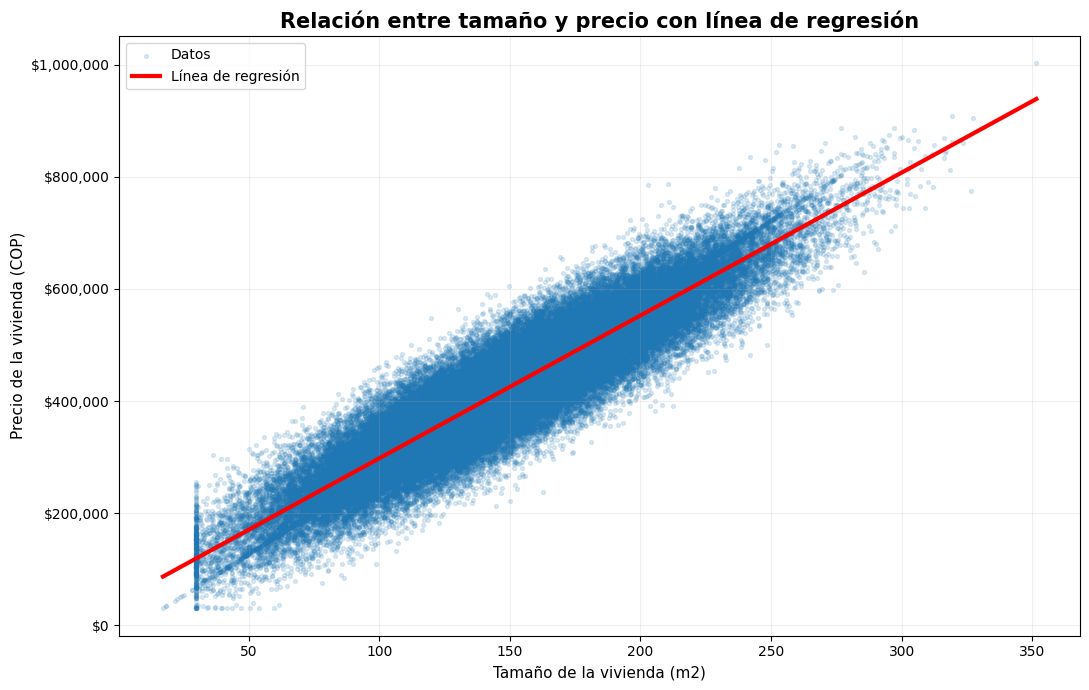

In [ ]:
# ============================================================
# 6.1 DATOS REALES Y LÍNEA DE REGRESIÓN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Crear valores ordenados de tamaño para dibujar la recta
tamano_linea = np.linspace(
    dataset_limpio['tamano'].min(),
    dataset_limpio['tamano'].max(),
    300
)

# Convertir al mismo formato utilizado en el entrenamiento
X_linea = pd.DataFrame({
    'tamano': tamano_linea
})

# Predecir precios sobre los valores de la línea
precio_linea = modelo.predict(X_linea)

# Crear gráfica
plt.figure(figsize=(11, 7))

# Datos del dataset imputado
plt.scatter(
    dataset_limpio['tamano'],
    dataset_limpio['precio'],
    alpha=0.15,
    s=8,
    label='Datos'
)

# Línea de regresión
plt.plot(
    tamano_linea,
    precio_linea,
    linewidth=3,
    label='Línea de regresión',
    color='red'
)

# Formato del eje del precio
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.title(
    'Relación entre tamaño y precio con línea de regresión',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Tamaño de la vivienda (m2)', fontsize=11)
plt.ylabel('Precio de la vivienda (COP)', fontsize=11)

plt.grid(alpha=0.20)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

El gráfico evidencia una **relación lineal positiva** entre el tamaño y el precio de las viviendas. La línea de regresión representa la tendencia estimada por el modelo: a medida que aumenta el tamaño de la vivienda, también aumenta su precio esperado.

## 6.2 Gráfico de residuos


Las predicciones del conjunto de prueba, que ya calculamos: `y_pred = modelo.predict(X_test)`

El residuo se calcula como:

$$Residuo= Precio_{real} − Precio_{estimado}$$

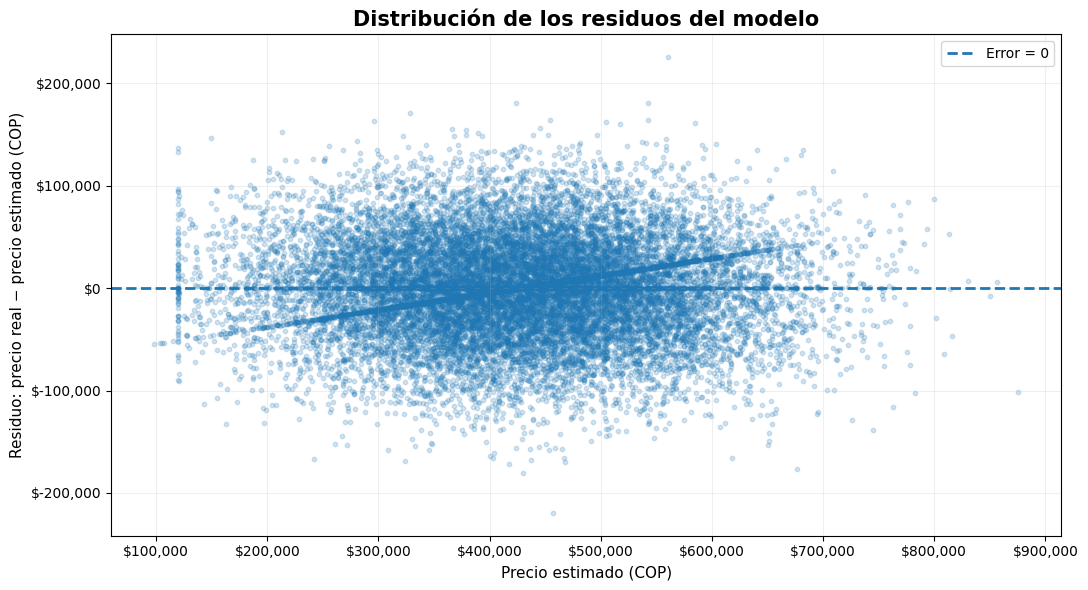

In [ ]:
# ============================================================
# 6.2 GRÁFICO DE RESIDUOS
# ============================================================

residuos = y_test.to_numpy() - y_pred

plt.figure(figsize=(11, 6))

plt.scatter(
    y_pred,
    residuos,
    alpha=0.20,
    s=10
)

# Línea de referencia en residuo = 0
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2,
    label='Error = 0'
)

# Formato de los ejes
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.title(
    'Distribución de los residuos del modelo',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Precio estimado (COP)', fontsize=11)
plt.ylabel('Residuo: precio real − precio estimado (COP)', fontsize=11)

plt.grid(alpha=0.20)
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

Los residuos se distribuyen principalmente alrededor de **cero**, sin evidenciar una curvatura marcada, lo que respalda el uso de un modelo lineal. Sin embargo, se observan algunos errores extremos y cierta estructura en la dispersión, probablemente asociada a los valores imputados. En general, el comportamiento de los residuos es consistente con el **buen desempeño predictivo** obtenido por el modelo.
